In [1]:
!apt-get -qq install fonts-nanum > /dev/null
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from collections import Counter
from scipy.stats import fisher_exact

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ------------------------------------------------------------------
# 데이터 로드 및 E(항히스타민+비충혈제거제) 그룹 추출
# ------------------------------------------------------------------
df = pd.read_csv('FDA_adverse_events_final.csv', low_memory=False)
r = df[df['WHO_ATC'] == 'R'].copy()

def first_segment(s):
    return '' if pd.isna(s) else s.split(';')[0]

r['first_seg'] = r['suspect_drug'].apply(first_segment)

def classify(s):
    s = s.upper()
    if re.search(r'^IBUPROFEN$', s):
        return 'D'
    if re.search(r'^ACETAMINOPHEN$', s):
        return 'G'
    if re.search(r'\bPM\b|SLEEPGEL|SLEEP.?AID|UNISOM', s):
        return 'D'
    if re.search(r'NAPROXEN', s) and re.search(r'DIPHENHYDRAMINE', s):
        return 'D'
    if re.search(r'-D\b|ALLEGRA.?D|ZYRTEC.?D', s) or \
       (re.search(r'PSEUDOEPHEDRINE', s) and re.search(r'CETIRIZINE|FEXOFENADINE|LORATADINE', s)):
        return 'E'
    if re.search(r'CETIRIZINE|FEXOFENADINE|LORATADINE|LEVOCETIRIZINE|DIPHENHYDRAMINE|REACTINE|XYZAL|ALLEGRA(?!.?D)', s):
        return 'A'
    if re.search(r'PSEUDOEPHEDRINE|PHENYLEPHRINE|OXYMETAZOLINE|SUDAFED', s):
        return 'C'
    if re.search(r'GUAIFENESIN|DEXTROMETHORPHAN', s):
        return 'B'
    if re.search(r'FLUTICASONE', s):
        return 'F'
    return 'H'

r['group'] = r['first_seg'].apply(classify)
e = r[r['group'] == 'E'].copy()
rest = df[~df.index.isin(e.index)].copy()
n_e, n_rest = len(e), len(rest)


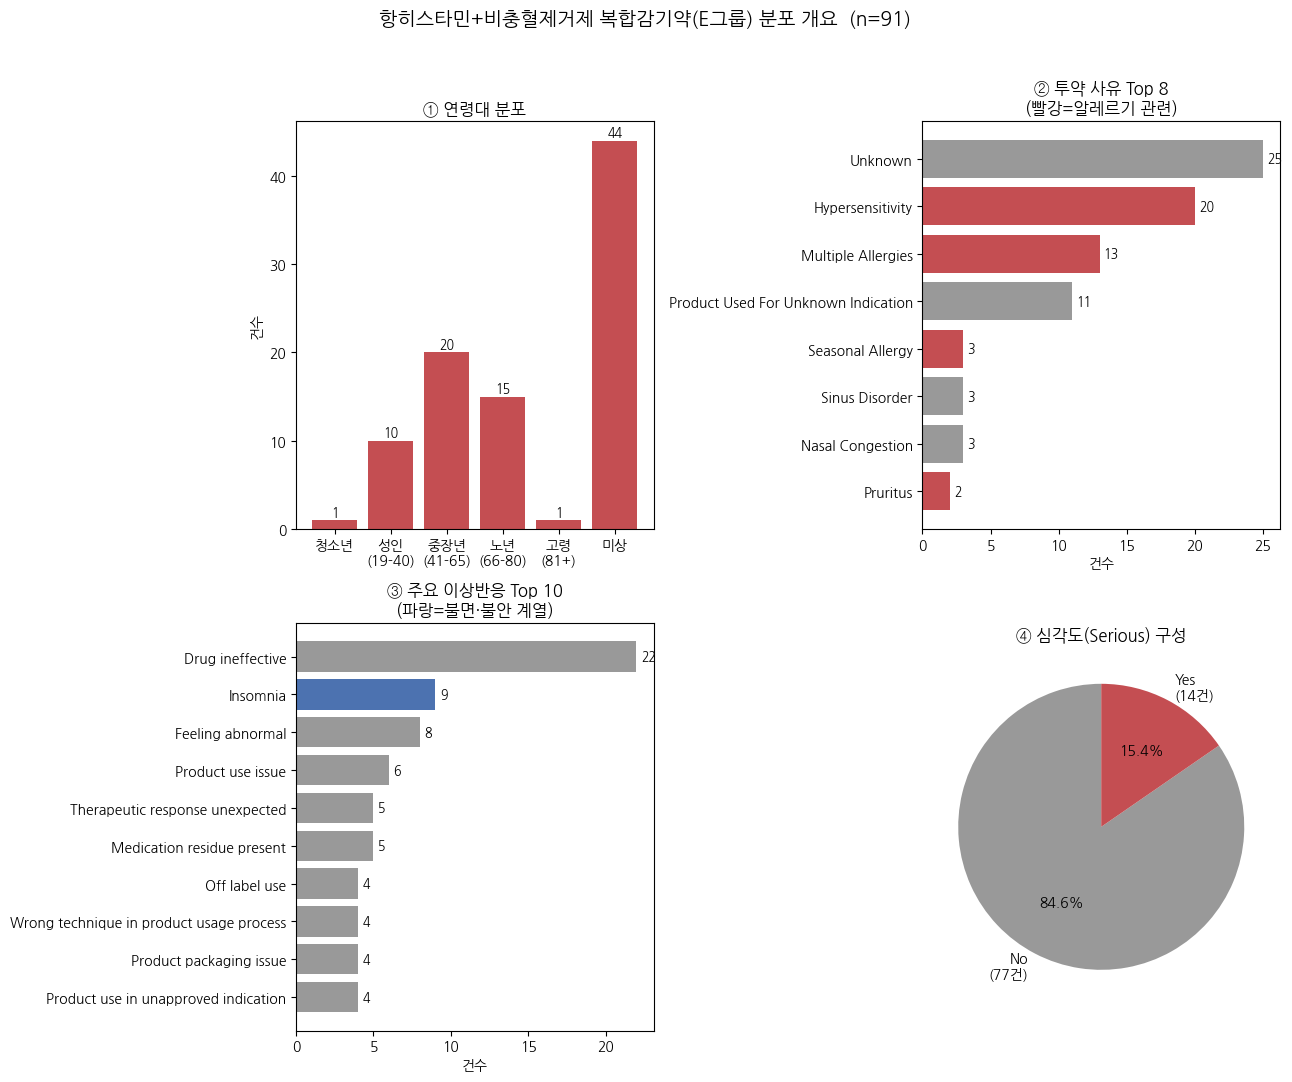

=== E그룹 개요 (n=91) ===

연령대:
age_group
Teen(13-18)            1
Adult(19-40)          10
Middle-Aged(41-65)    20
Senior(66-80)         15
Elderly(81+)           1
Unknown               44
Name: count, dtype: int64

투약 사유 Top 8:
drug_indication
Unknown                                25
Hypersensitivity                       20
Multiple Allergies                     13
Product Used For Unknown Indication    11
Seasonal Allergy                        3
Sinus Disorder                          3
Nasal Congestion                        3
Pruritus                                2
Name: count, dtype: int64

이상반응 Top 10:
  Drug ineffective                    22건
  Insomnia                            9건
  Feeling abnormal                    8건
  Product use issue                   6건
  Therapeutic response unexpected     5건
  Medication residue present          5건
  Off label use                       4건
  Wrong technique in product usage process 4건
  Product packaging issue             4건
  Pro

In [2]:
MAIN = '#C44E52'
ACCENT = '#4C72B0'
GREY = '#999999'

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
fig.suptitle(f'항히스타민+비충혈제거제 복합감기약(E그룹) 분포 개요  (n={n_e})',
             fontsize=14, fontweight='bold', y=0.98)

# ==================================================================
# ① 연령대 분포
# ==================================================================
ax = axes[0, 0]
age_order = ['Teen(13-18)', 'Adult(19-40)', 'Middle-Aged(41-65)', 'Senior(66-80)', 'Elderly(81+)', 'Unknown']
age_labels = ['청소년', '성인\n(19-40)', '중장년\n(41-65)', '노년\n(66-80)', '고령\n(81+)', '미상']
age_cnt = e['age_group'].value_counts().reindex(age_order).fillna(0)
ax.bar(age_labels, age_cnt, color=MAIN)
for i, v in enumerate(age_cnt):
    ax.text(i, v + 0.5, f'{int(v)}', ha='center', fontsize=9)
ax.set_title('① 연령대 분포', fontsize=12, fontweight='bold')
ax.set_ylabel('건수')

# ==================================================================
# ② 투약 사유(적응증) Top 8
# ==================================================================
ax = axes[0, 1]
indication_cnt = e['drug_indication'].value_counts().head(8)[::-1]
colors_ind = [MAIN if 'llerg' in idx or 'ypersensitiv' in idx or 'ruritus' in idx else GREY
              for idx in indication_cnt.index]
ax.barh(indication_cnt.index, indication_cnt.values, color=colors_ind)
for i, v in enumerate(indication_cnt.values):
    ax.text(v + 0.3, i, f'{v}', va='center', fontsize=9)
ax.set_title('② 투약 사유 Top 8\n(빨강=알레르기 관련)', fontsize=12, fontweight='bold')
ax.set_xlabel('건수')

# ==================================================================
# ③ 주요 이상반응 Top 10 (개별 반응 풀어서)
# ==================================================================
ax = axes[1, 0]
all_reactions = []
for s in e['reactions'].dropna():
    all_reactions.extend([p.strip() for p in s.split(';')])
cnt = Counter(all_reactions)
top10 = cnt.most_common(10)
labels = [t for t, c in top10][::-1]
values = [c for t, c in top10][::-1]
colors_reac = [ACCENT if lbl in ('Insomnia', 'Nervousness') else GREY for lbl in labels]
ax.barh(labels, values, color=colors_reac)
for i, v in enumerate(values):
    ax.text(v + 0.3, i, f'{v}', va='center', fontsize=9)
ax.set_title('③ 주요 이상반응 Top 10\n(파랑=불면·불안 계열)', fontsize=12, fontweight='bold')
ax.set_xlabel('건수')

# ==================================================================
# ④ 심각도 구성
# ==================================================================
ax = axes[1, 1]
serious_cnt = e['serious'].value_counts()
colors_pie = [GREY, MAIN] if 'No' in serious_cnt.index else [MAIN]
ax.pie(serious_cnt.values, labels=[f'{idx}\n({v}건)' for idx, v in serious_cnt.items()],
       colors=colors_pie, autopct='%1.1f%%', startangle=90,
       textprops={'fontsize': 10})
ax.set_title('④ 심각도(Serious) 구성', fontsize=12, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# 콘솔 요약
print(f"=== E그룹 개요 (n={n_e}) ===")
print("\n연령대:")
print(age_cnt)
print("\n투약 사유 Top 8:")
print(indication_cnt[::-1])
print("\n이상반응 Top 10:")
for t, c in top10:
    print(f"  {t:35s} {c}건")
print("\n심각도:")
print(serious_cnt)


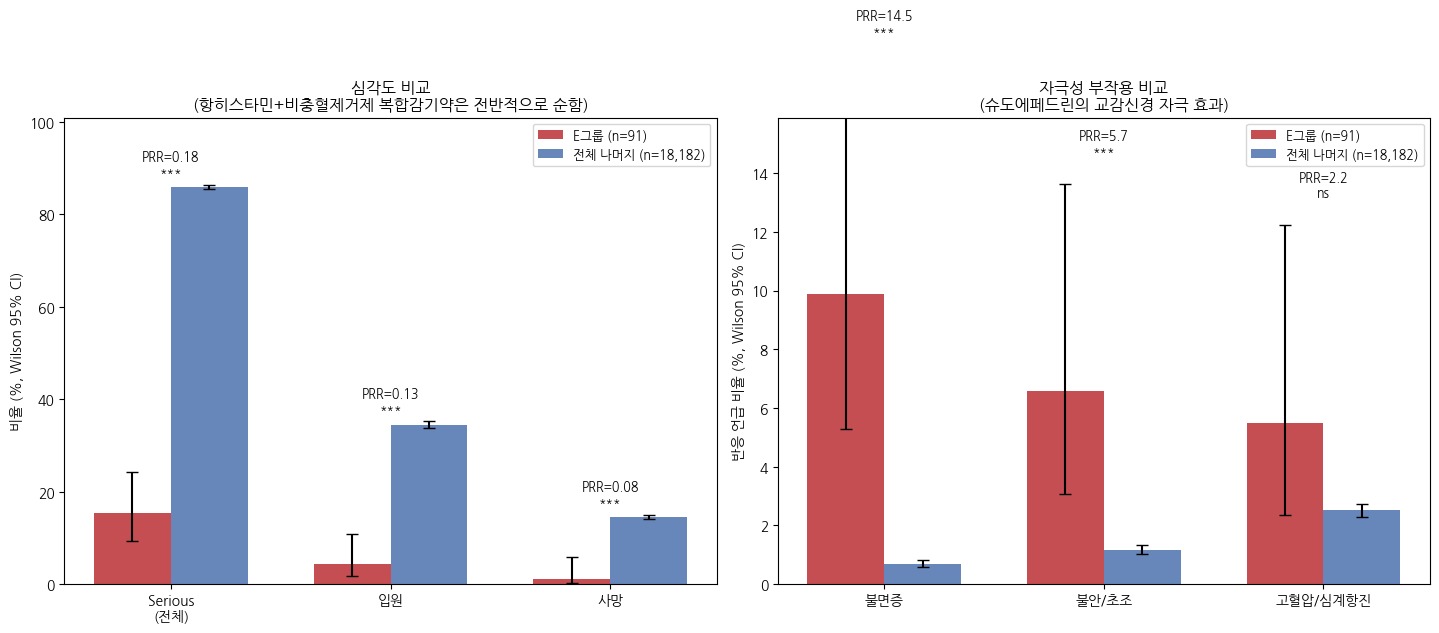

=== 심각도 ===
Serious (전체)    E 15.4% vs 전체 85.9%  PRR=0.18  p=9.6e-51
입원              E 4.4% vs 전체 34.5%  PRR=0.13  p=7.2e-12
사망              E 1.1% vs 전체 14.5%  PRR=0.08  p=1.7e-05

=== 자극성 부작용 ===
불면증             E 9.9% vs 전체 0.7%  PRR=14.50  p=2.1e-08
불안/초조           E 6.6% vs 전체 1.2%  PRR=5.68  p=7.5e-04
고혈압/심계항진        E 5.5% vs 전체 2.5%  PRR=2.19  p=8.0e-02


In [3]:
RED = '#C44E52'
BLUE = '#4C72B0'

def wilson_ci(k, n, z=1.96):
    p = k / n
    denom = 1 + z**2 / n
    center = p + z**2 / (2 * n)
    margin = z * np.sqrt((p * (1 - p) / n) + (z**2 / (4 * n**2)))
    return (center - margin) / denom, (center + margin) / denom

def sig_stars(p):
    return '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14.5, 6.5))

# ==================================================================
# 왼쪽: 심각도 비교 (전반적으로 순함을 보여줌)
# ==================================================================
severity_metrics = [('serious', 'Serious\n(전체)'), ('is_hospitalized', '입원'), ('is_fatal', '사망')]
rows1 = []
for col, label in severity_metrics:
    k1 = (e[col] == 'Yes').sum() if e[col].dtype != bool else e[col].sum()
    k2 = (rest[col] == 'Yes').sum() if rest[col].dtype != bool else rest[col].sum()
    p1, p2 = k1 / n_e, k2 / n_rest
    prr = p1 / p2 if p2 > 0 else np.nan
    _, p_fisher = fisher_exact([[k1, n_e - k1], [k2, n_rest - k2]])
    lo1, hi1 = wilson_ci(k1, n_e)
    lo2, hi2 = wilson_ci(k2, n_rest)
    rows1.append(dict(label=label, p1=p1*100, p2=p2*100, prr=prr, p_fisher=p_fisher,
                       err1=(p1*100-lo1*100, hi1*100-p1*100), err2=(p2*100-lo2*100, hi2*100-p2*100)))

x1 = np.arange(len(rows1))
w = 0.35
p1_vals = [row['p1'] for row in rows1]
p2_vals = [row['p2'] for row in rows1]
err1 = np.array([row['err1'] for row in rows1]).T
err2 = np.array([row['err2'] for row in rows1]).T

ax1.bar(x1 - w/2, p1_vals, width=w, color=RED, yerr=err1, capsize=4, label=f'E그룹 (n={n_e})')
ax1.bar(x1 + w/2, p2_vals, width=w, color=BLUE, alpha=0.85, yerr=err2, capsize=4, label=f'전체 나머지 (n={n_rest:,})')

for i, row in enumerate(rows1):
    top = max(row['p1'] + row['err1'][1], row['p2'] + row['err2'][1])
    ax1.text(i, top + 2, f"PRR={row['prr']:.2f}\n{sig_stars(row['p_fisher'])}", ha='center', fontsize=9, fontweight='bold')

ax1.set_xticks(x1)
ax1.set_xticklabels([row['label'] for row in rows1])
ax1.set_ylabel('비율 (%, Wilson 95% CI)')
ax1.set_title('심각도 비교\n(항히스타민+비충혈제거제 복합감기약은 전반적으로 순함)', fontsize=11.5, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)
ax1.set_ylim(0, max(p1_vals + p2_vals) + 15)

# ==================================================================
# 오른쪽: 자극성 부작용 (슈도에페드린 교감신경 자극 효과)
# ==================================================================
stim_items = [
    ('불면증', 'insomnia'),
    ('불안/초조', 'anxiety|nervous|agitat'),
    ('고혈압/심계항진', 'hypertens|palpitation|tachycardi'),
]
rows2 = []
for label, pattern in stim_items:
    k1 = e['reactions'].str.contains(pattern, case=False, na=False).sum()
    k2 = rest['reactions'].str.contains(pattern, case=False, na=False).sum()
    p1, p2 = k1 / n_e, k2 / n_rest
    prr = p1 / p2 if p2 > 0 else np.nan
    _, p_fisher = fisher_exact([[k1, n_e - k1], [k2, n_rest - k2]])
    lo1, hi1 = wilson_ci(k1, n_e)
    lo2, hi2 = wilson_ci(k2, n_rest)
    rows2.append(dict(label=label, p1=p1*100, p2=p2*100, prr=prr, p_fisher=p_fisher,
                       err1=(p1*100-lo1*100, hi1*100-p1*100), err2=(p2*100-lo2*100, hi2*100-p2*100)))

x2 = np.arange(len(rows2))
p1_vals2 = [row['p1'] for row in rows2]
p2_vals2 = [row['p2'] for row in rows2]
err1_2 = np.array([row['err1'] for row in rows2]).T
err2_2 = np.array([row['err2'] for row in rows2]).T

ax2.bar(x2 - w/2, p1_vals2, width=w, color=RED, yerr=err1_2, capsize=4, label=f'E그룹 (n={n_e})')
ax2.bar(x2 + w/2, p2_vals2, width=w, color=BLUE, alpha=0.85, yerr=err2_2, capsize=4, label=f'전체 나머지 (n={n_rest:,})')

for i, row in enumerate(rows2):
    top = max(row['p1'] + row['err1'][1], row['p2'] + row['err2'][1])
    ax2.text(i, top + 1, f"PRR={row['prr']:.1f}\n{sig_stars(row['p_fisher'])}", ha='center', fontsize=9, fontweight='bold')

ax2.set_xticks(x2)
ax2.set_xticklabels([row['label'] for row in rows2])
ax2.set_ylabel('반응 언급 비율 (%, Wilson 95% CI)')
ax2.set_title('자극성 부작용 비교\n(슈도에페드린의 교감신경 자극 효과)', fontsize=11.5, fontweight='bold')
ax2.legend(loc='upper right', fontsize=9)
ax2.set_ylim(0, max(p1_vals2 + p2_vals2) + 6)

plt.tight_layout()
plt.show()

# 콘솔 요약
print("=== 심각도 ===")
for row in rows1:
    print(f"{row['label'].replace(chr(10),' '):15s} E {row['p1']:.1f}% vs 전체 {row['p2']:.1f}%  PRR={row['prr']:.2f}  p={row['p_fisher']:.1e}")
print()
print("=== 자극성 부작용 ===")
for row in rows2:
    print(f"{row['label']:15s} E {row['p1']:.1f}% vs 전체 {row['p2']:.1f}%  PRR={row['prr']:.2f}  p={row['p_fisher']:.1e}")


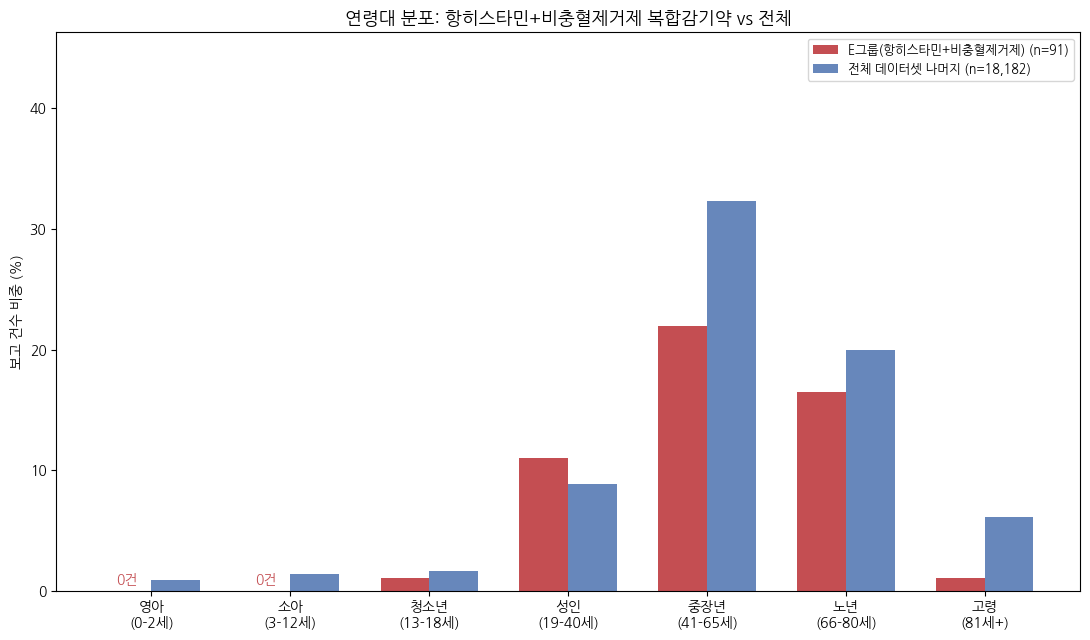

=== 연령대 분포 ===
영아 (0-2세)       E   0.0% (n=0)  전체   0.9%
소아 (3-12세)      E   0.0% (n=0)  전체   1.4%
청소년 (13-18세)    E   1.1% (n=1)  전체   1.7%
성인 (19-40세)     E  11.0% (n=10)  전체   8.9%
중장년 (41-65세)    E  22.0% (n=20)  전체  32.3%
노년 (66-80세)     E  16.5% (n=15)  전체  20.0%
고령 (81세+)       E   1.1% (n=1)  전체   6.1%


In [4]:
RED = '#C44E52'
BLUE = '#4C72B0'
GREY = '#555555'

age_order = ['Infant(0-2)', 'Child(3-12)', 'Teen(13-18)', 'Adult(19-40)',
             'Middle-Aged(41-65)', 'Senior(66-80)', 'Elderly(81+)']
age_labels = ['영아\n(0-2세)', '소아\n(3-12세)', '청소년\n(13-18세)', '성인\n(19-40세)',
              '중장년\n(41-65세)', '노년\n(66-80세)', '고령\n(81세+)']

e_pct = e['age_group'].value_counts(normalize=True).reindex(age_order).fillna(0) * 100
rest_pct = rest['age_group'].value_counts(normalize=True).reindex(age_order).fillna(0) * 100
e_cnt = e['age_group'].value_counts().reindex(age_order).fillna(0)

fig, ax = plt.subplots(figsize=(11, 6.5))
x = np.arange(len(age_order))
w = 0.35

ax.bar(x - w/2, e_pct, width=w, color=RED, label=f'E그룹(항히스타민+비충혈제거제) (n={n_e})')
ax.bar(x + w/2, rest_pct, width=w, color=BLUE, alpha=0.85, label=f'전체 데이터셋 나머지 (n={n_rest:,})')

ax.set_xticks(x)
ax.set_xticklabels(age_labels)
ax.set_ylabel('보고 건수 비중 (%)')
ax.set_title('연령대 분포: 항히스타민+비충혈제거제 복합감기약 vs 전체', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, max(e_pct.max(), rest_pct.max()) + 14)

for i in [0, 1]:
    ax.text(i - w/2, 0.6, '0건', ha='center', fontsize=10, fontweight='bold', color=RED)

plt.tight_layout()
plt.show()

# 콘솔 요약
print("=== 연령대 분포 ===")
for ag, lbl in zip(age_order, age_labels):
    print(f"{lbl.replace(chr(10),' '):15s} E {e_pct[ag]:5.1f}% (n={int(e_cnt[ag])})  전체 {rest_pct[ag]:5.1f}%")
